# EEG Feature Hierarchy Comparison with Multimodal Late Fusion

This notebook compares **5 hierarchical EEG feature extraction strategies** in full multimodal late fusion:

| Level | Strategy | Features | Description |
|-------|----------|----------|-------------|
| 0 | `channels_raw` | 20 | Total power per electrode (base) |
| 1 | `regional_raw` | 4 | Regional averages of total power |
| 2 | `channels_bands` | 80 | 20 channels × 4 frequency bands |
| 3 | `regional_bands` | 16 | 4 regions × 4 frequency bands |
| 4 | `extended` | 160 | channels_bands + lateralization + temporal |

For each EEG feature set, we:
- Evaluate EEG features alone (single modality)
- Run full late fusion with physiology, behavior, gaze, and EEG
- Compare overall fusion accuracy and modality contributions

**Goal:** Determine which EEG feature granularity contributes most to multimodal decision prediction,
and perform systematic ablation to understand the value of each feature engineering step.

In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
TIMEFRAME = 'PRE'  # Fixed to PRE - EEG is from display/decision phase
# ============================================================================

import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.utils.io import load_features, save_results
from src.utils.config import get_model_params
from src.utils.validation import validate_modality_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import set_style, plot_method_comparison, plot_modality_weights
from src.features.eeg_features import get_strategy_hierarchy, CHANNEL_NAMES, CHANNEL_REGIONS, FREQ_BANDS

np.random.seed(42)
set_style('whitegrid')

# Display hierarchy
hierarchy = get_strategy_hierarchy()
print(f"\n{'='*70}")
print(f"EEG FEATURE HIERARCHY COMPARISON ({TIMEFRAME})")
print(f"{'='*70}\n")
print("Strategy Hierarchy:")
for strat, info in hierarchy.items():
    builds_on = info['builds_on'] or 'Base'
    print(f"  Level {info['level']}: {strat:20s} ({info['n_features']:3d} features) <- {builds_on}")


EEG FEATURE HIERARCHY COMPARISON (PRE)

Strategy Hierarchy:
  Level 0: channels_raw         ( 20 features) <- Base
  Level 1: regional_raw         (  4 features) <- channels_raw
  Level 2: channels_bands       ( 80 features) <- channels_raw
  Level 3: regional_bands       ( 16 features) <- channels_bands
  Level 4: extended             (112 features) <- channels_bands


## 1. Load Base Features (Physio, Behavior, Gaze)

In [2]:
# Load base features (physio, behavior, gaze)
features_path = f'../../data/features/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")
print(f"\nFeature counts:")
print(f"  Physiology: {len(physio_cols)} features")
print(f"  Behavior:   {len(behavior_cols)} features")
print(f"  Gaze:       {len(gaze_cols)} features")

Loaded 12107 trials from 102 subjects

Feature counts:
  Physiology: 13 features
  Behavior:   11 features
  Gaze:       20 features


## 2. Load All EEG Feature Sets (Hierarchical)

In [3]:
# Define EEG feature files for each strategy level
eeg_feature_files = {
    'L0: channels_raw': 'eeg_features_channels_raw.pkl',
    'L1: regional_raw': 'eeg_features_regional_raw.pkl',
    'L2: channels_bands': 'eeg_features_channels_bands.pkl',
    'L3: regional_bands': 'eeg_features_regional_bands.pkl',
    'L4: extended': 'eeg_features_extended.pkl'
}

# Load all EEG feature sets
eeg_datasets = {}

print(f"\n{'='*70}")
print("LOADING EEG FEATURE SETS")
print(f"{'='*70}\n")

for name, filename in eeg_feature_files.items():
    filepath = f'../../data/features/{filename}'
    try:
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
            level = data['metadata'].get('level', 'N/A')
            eeg_datasets[name] = {
                'df': data['eeg_features_df'],
                'cols': data['feature_columns'],
                'n_features': len(data['feature_columns']),
                'level': level,
                'metadata': data['metadata']
            }
        print(f"✓ {name}: {eeg_datasets[name]['n_features']} features")
    except FileNotFoundError:
        print(f"✗ {name}: Not found - run 01_eeg_feature_extraction.ipynb with STRATEGY='{filename.replace('eeg_features_', '').replace('.pkl', '')}'")

if len(eeg_datasets) == 0:
    raise RuntimeError("No EEG features loaded. Run extraction notebook first.")

print(f"\nLoaded {len(eeg_datasets)}/{len(eeg_feature_files)} feature sets")


LOADING EEG FEATURE SETS

✓ L0: channels_raw: 20 features
✓ L1: regional_raw: 4 features
✓ L2: channels_bands: 80 features
✓ L3: regional_bands: 16 features
✓ L4: extended: 160 features

Loaded 5/5 feature sets


## 3. Feature Listings by Strategy Level

In [4]:
print(f"\n{'='*70}")
print(f"FEATURE LISTINGS BY STRATEGY LEVEL")
print(f"{'='*70}\n")

for name, data in eeg_datasets.items():
    print(f"\n{name} ({data['n_features']} features):")
    print("-" * 60)
    
    cols = data['cols']
    
    # Show first 10 features
    for feat in cols[:10]:
        print(f"  - {feat}")
    if len(cols) > 10:
        print(f"  ... and {len(cols) - 10} more")
    print()


FEATURE LISTINGS BY STRATEGY LEVEL


L0: channels_raw (20 features):
------------------------------------------------------------
  - eeg_Fp1
  - eeg_F7
  - eeg_F8
  - eeg_T4
  - eeg_T6
  - eeg_T5
  - eeg_T3
  - eeg_Fp2
  - eeg_O1
  - eeg_P3
  ... and 10 more


L1: regional_raw (4 features):
------------------------------------------------------------
  - eeg_Frontal
  - eeg_Central
  - eeg_Parietal
  - eeg_Occipital


L2: channels_bands (80 features):
------------------------------------------------------------
  - eeg_Delta_Fp1
  - eeg_Delta_F7
  - eeg_Delta_F8
  - eeg_Delta_T4
  - eeg_Delta_T6
  - eeg_Delta_T5
  - eeg_Delta_T3
  - eeg_Delta_Fp2
  - eeg_Delta_O1
  - eeg_Delta_P3
  ... and 70 more


L3: regional_bands (16 features):
------------------------------------------------------------
  - eeg_Delta_Frontal
  - eeg_Delta_Central
  - eeg_Delta_Parietal
  - eeg_Delta_Occipital
  - eeg_Theta_Frontal
  - eeg_Theta_Central
  - eeg_Theta_Parietal
  - eeg_Theta_Occipital
  - eeg_Alph

## 4. EEG-Only Evaluation (Single Modality)

In [5]:
def evaluate_eeg_features(merged_df, eeg_df, eeg_cols, feature_set_name):
    """
    Evaluate EEG features using LOSO cross-validation.
    """
    # Get EEG subjects and filter
    eeg_subjects = eeg_df['subject_id'].unique()
    merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
    
    # Merge with EEG features
    merged_df_eeg = merged_df_eeg.merge(
        eeg_df[['trial_id'] + list(eeg_cols)],
        on='trial_id',
        how='inner'
    )
    
    print(f"\n{feature_set_name}")
    print(f"  Subjects: {merged_df_eeg['subject_id'].nunique()}, Trials: {len(merged_df_eeg)}, Features: {len(eeg_cols)}")
    
    # Prepare data
    X = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[eeg_cols])
    y = merged_df_eeg['outcome'].values
    subjects = merged_df_eeg['subject_id'].values
    
    # LOSO cross-validation
    logo = LeaveOneGroupOut()
    model_params = get_model_params('random_forest')
    
    subject_accs = []
    subject_f1s = []
    all_importances = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = RandomForestClassifier(**model_params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        subject_accs.append(acc)
        subject_f1s.append(f1)
        all_importances.append(model.feature_importances_)
    
    overall_acc = np.mean(subject_accs)
    overall_f1 = np.mean(subject_f1s)
    acc_sem = stats.sem(subject_accs)
    f1_sem = stats.sem(subject_f1s)
    avg_importances = np.mean(all_importances, axis=0)
    
    print(f"  Accuracy: {overall_acc:.3f} ± {acc_sem:.3f}, F1: {overall_f1:.3f} ± {f1_sem:.3f}")
    
    feature_importance_df = pd.DataFrame({
        'Feature': eeg_cols,
        'Importance': avg_importances
    }).sort_values('Importance', ascending=False)
    
    return {
        'name': feature_set_name,
        'n_features': len(eeg_cols),
        'n_subjects': merged_df_eeg['subject_id'].nunique(),
        'n_trials': len(merged_df_eeg),
        'accuracy': overall_acc,
        'accuracy_sem': acc_sem,
        'f1': overall_f1,
        'f1_sem': f1_sem,
        'feature_importances': feature_importance_df
    }

In [6]:
# Evaluate each EEG feature set (single modality)
print(f"\n{'='*70}")
print(f"EEG-ONLY EVALUATION (Single Modality)")
print(f"{'='*70}")

eeg_only_results = {}

for name, data in eeg_datasets.items():
    eeg_only_results[name] = evaluate_eeg_features(
        merged_df,
        data['df'],
        data['cols'],
        name
    )


EEG-ONLY EVALUATION (Single Modality)

L0: channels_raw
  Subjects: 80, Trials: 9365, Features: 20


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


  Accuracy: 0.549 ± 0.018, F1: 0.528 ± 0.021

L1: regional_raw
  Subjects: 80, Trials: 9365, Features: 4
  Accuracy: 0.541 ± 0.017, F1: 0.529 ± 0.020

L2: channels_bands
  Subjects: 80, Trials: 9365, Features: 80
  Accuracy: 0.558 ± 0.018, F1: 0.538 ± 0.020

L3: regional_bands
  Subjects: 80, Trials: 9365, Features: 16
  Accuracy: 0.566 ± 0.017, F1: 0.547 ± 0.020

L4: extended
  Subjects: 80, Trials: 9365, Features: 160
  Accuracy: 0.555 ± 0.018, F1: 0.534 ± 0.021


In [7]:
# Compare EEG-only results
eeg_only_df = pd.DataFrame([
    {
        'Strategy': r['name'],
        'N Features': r['n_features'],
        'Accuracy': r['accuracy'],
        'Accuracy SEM': r['accuracy_sem'],
        'F1-Score': r['f1'],
        'F1 SEM': r['f1_sem']
    }
    for r in eeg_only_results.values()
])

print(f"\n{'='*70}")
print(f"EEG-ONLY COMPARISON SUMMARY")
print(f"{'='*70}")
print(eeg_only_df.to_string(index=False))

# Best EEG-only
best_eeg = eeg_only_df.loc[eeg_only_df['Accuracy'].idxmax()]
print(f"\nBest EEG-only: {best_eeg['Strategy']} (Acc={best_eeg['Accuracy']:.3f})")


EEG-ONLY COMPARISON SUMMARY
          Strategy  N Features  Accuracy  Accuracy SEM  F1-Score   F1 SEM
  L0: channels_raw          20  0.549089      0.017938  0.527566 0.021119
  L1: regional_raw           4  0.540943      0.017312  0.528793 0.020409
L2: channels_bands          80  0.557544      0.017643  0.538189 0.020483
L3: regional_bands          16  0.565707      0.017463  0.547251 0.020409
      L4: extended         160  0.554557      0.017589  0.533546 0.020509

Best EEG-only: L3: regional_bands (Acc=0.566)


## 5. Ablation Analysis: Does Each Level Add Value?

In [8]:
print(f"\n{'='*70}")
print(f"ABLATION ANALYSIS: Value of Each Feature Engineering Step")
print(f"{'='*70}\n")

# Define comparisons
comparisons = [
    ('L0: channels_raw', 'L1: regional_raw', 'Regional aggregation (L0→L1)'),
    ('L0: channels_raw', 'L2: channels_bands', 'Band decomposition (L0→L2)'),
    ('L2: channels_bands', 'L3: regional_bands', 'Regional aggregation with bands (L2→L3)'),
    ('L2: channels_bands', 'L4: extended', 'Adding temporal + lateralization (L2→L4)'),
]

print("Key Questions:")
print("-" * 60)

for base, compare, question in comparisons:
    if base in eeg_only_results and compare in eeg_only_results:
        base_acc = eeg_only_results[base]['accuracy']
        compare_acc = eeg_only_results[compare]['accuracy']
        diff = compare_acc - base_acc
        direction = "↑" if diff > 0 else "↓" if diff < 0 else "="
        
        print(f"\n{question}")
        print(f"  {base}: {base_acc:.3f}")
        print(f"  {compare}: {compare_acc:.3f}")
        print(f"  Difference: {direction} {abs(diff):.3f}")
    else:
        print(f"\n{question}")
        print(f"  [Missing data for comparison]")


ABLATION ANALYSIS: Value of Each Feature Engineering Step

Key Questions:
------------------------------------------------------------

Regional aggregation (L0→L1)
  L0: channels_raw: 0.549
  L1: regional_raw: 0.541
  Difference: ↓ 0.008

Band decomposition (L0→L2)
  L0: channels_raw: 0.549
  L2: channels_bands: 0.558
  Difference: ↑ 0.008

Regional aggregation with bands (L2→L3)
  L2: channels_bands: 0.558
  L3: regional_bands: 0.566
  Difference: ↑ 0.008

Adding temporal + lateralization (L2→L4)
  L2: channels_bands: 0.558
  L4: extended: 0.555
  Difference: ↓ 0.003


## 6. Multimodal Late Fusion with Each EEG Feature Set

In [9]:
def run_multimodal_fusion(merged_df, physio_cols, behavior_cols, gaze_cols,
                           eeg_df, eeg_cols, eeg_name):
    """
    Run full late fusion with all modalities.
    """
    # Filter to EEG subjects and merge
    eeg_subjects = eeg_df['subject_id'].unique()
    merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
    
    merged_df_eeg = merged_df_eeg.merge(
        eeg_df[['trial_id'] + list(eeg_cols)],
        on='trial_id',
        how='inner'
    )
    
    print(f"\n{eeg_name}: {len(eeg_cols)} EEG features, {merged_df_eeg['subject_id'].nunique()} subjects")
    
    # Prepare modality arrays
    X_physio = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[physio_cols])
    X_behavior = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[behavior_cols])
    X_gaze = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[gaze_cols]) if len(gaze_cols) > 0 else np.zeros((len(merged_df_eeg), 1))
    X_eeg = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[eeg_cols])
    
    y = merged_df_eeg['outcome'].values
    subjects = merged_df_eeg['subject_id'].values
    
    # Validate and run fusion
    modality_names = ['Physiology', 'Behavior', 'Gaze', 'EEG']
    X_modalities = [X_physio, X_behavior, X_gaze, X_eeg]
    validate_modality_features(X_modalities, y, subjects, modality_names)
    
    results_weighted = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                            fusion_method='weighted')
    results_stacking = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                            fusion_method='stacking')
    
    print(f"  Weighted: {results_weighted['accuracy_mean']:.3f}, Stacking: {results_stacking['accuracy_mean']:.3f}")
    print(f"  EEG weight: {results_weighted['weights'][3]*100:.1f}%")
    
    return {
        'eeg_name': eeg_name,
        'n_eeg_features': len(eeg_cols),
        'results_weighted': results_weighted,
        'results_stacking': results_stacking,
        'modality_names': modality_names
    }

In [ ]:
# Run multimodal fusion for each EEG feature set
print(f"\n{'='*70}")
print(f"MULTIMODAL LATE FUSION")
print(f"{'='*70}")

fusion_results = {}

for eeg_name, eeg_data in eeg_datasets.items():
    fusion_results[eeg_name] = run_multimodal_fusion(
        merged_df,
        physio_cols,
        behavior_cols,
        gaze_cols,
        eeg_data['df'],
        eeg_data['cols'],
        eeg_name
    )


MULTIMODAL LATE FUSION



L0: channels_raw: 20 EEG features, 80 subjects
✓ Modality validation passed:
  Physiology: 9365 samples × 13 features
  Behavior: 9365 samples × 11 features
  Gaze: 9365 samples × 20 features
  EEG: 9365 samples × 20 features
  Weighted: 0.750, Stacking: 0.722
  EEG weight: 0.1%

L1: regional_raw: 4 EEG features, 80 subjects
✓ Modality validation passed:
  Physiology: 9365 samples × 13 features
  Behavior: 9365 samples × 11 features
  Gaze: 9365 samples × 20 features
  EEG: 9365 samples × 4 features
  Weighted: 0.749, Stacking: 0.721
  EEG weight: 0.1%

L2: channels_bands: 80 EEG features, 80 subjects
✓ Modality validation passed:
  Physiology: 9365 samples × 13 features
  Behavior: 9365 samples × 11 features
  Gaze: 9365 samples × 20 features
  EEG: 9365 samples × 80 features


## 7. Compare Multimodal Fusion Results

In [ ]:
# Build comparison dataframe for multimodal fusion
multimodal_comparison = []

for eeg_name, result in fusion_results.items():
    multimodal_comparison.extend([
        {
            'EEG Strategy': eeg_name,
            'N EEG Features': result['n_eeg_features'],
            'Method': 'Weighted',
            'Accuracy': result['results_weighted']['accuracy_mean'],
            'Accuracy SEM': result['results_weighted']['accuracy_sem'],
            'EEG Weight': result['results_weighted']['weights'][3] * 100
        },
        {
            'EEG Strategy': eeg_name,
            'N EEG Features': result['n_eeg_features'],
            'Method': 'Stacking',
            'Accuracy': result['results_stacking']['accuracy_mean'],
            'Accuracy SEM': result['results_stacking']['accuracy_sem'],
            'EEG Weight': np.nan  # Stacking doesn't have explicit weights
        }
    ])

multimodal_df = pd.DataFrame(multimodal_comparison)

print(f"\n{'='*70}")
print(f"MULTIMODAL LATE FUSION COMPARISON")
print(f"{'='*70}")
print(multimodal_df[multimodal_df['Method'] == 'Weighted'].to_string(index=False))

# Find best
best_multi = multimodal_df.loc[multimodal_df['Accuracy'].idxmax()]
print(f"\nBest: {best_multi['EEG Strategy']} + {best_multi['Method']} (Acc={best_multi['Accuracy']:.3f})")


MULTIMODAL LATE FUSION COMPARISON
      EEG Strategy  N EEG Features   Method  Accuracy  Accuracy SEM  EEG Weight
  L0: channels_raw              20 Weighted  0.747713      0.014488    0.475755
  L1: regional_raw               4 Weighted  0.746920      0.014477    0.408206
L2: channels_bands              80 Weighted  0.747892      0.014462    0.665581
L3: regional_bands              16 Weighted  0.747735      0.014439    0.471276
      L4: extended             160 Weighted  0.747827      0.014436    0.888909

Best: L2: channels_bands + Weighted (Acc=0.748)


## 8. Visualization: EEG-Only vs Multimodal by Strategy Level

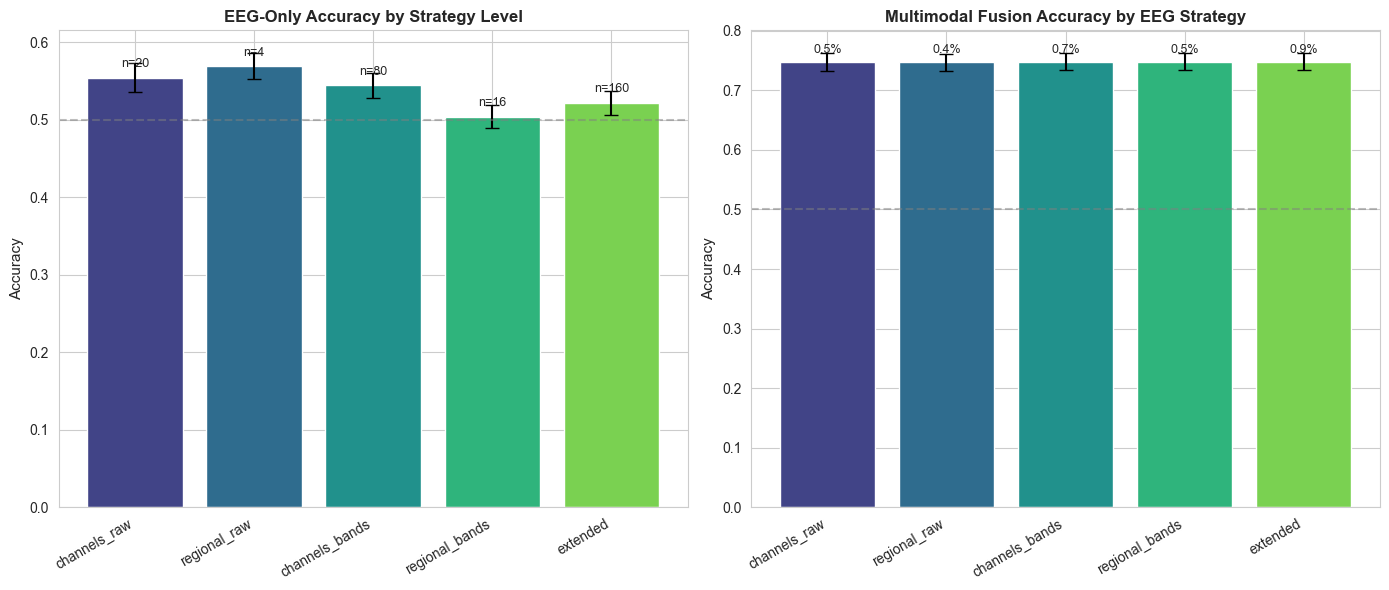

In [ ]:
# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

strategies = list(eeg_datasets.keys())
x_pos = np.arange(len(strategies))

# Plot 1: EEG-only accuracy by strategy
ax1 = axes[0]
eeg_accs = [eeg_only_results[s]['accuracy'] for s in strategies]
eeg_sems = [eeg_only_results[s]['accuracy_sem'] for s in strategies]
n_feats = [eeg_datasets[s]['n_features'] for s in strategies]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(strategies)))
bars1 = ax1.bar(x_pos, eeg_accs, yerr=eeg_sems, color=colors, capsize=5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([s.split(': ')[1] for s in strategies], rotation=30, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('EEG-Only Accuracy by Strategy Level', fontweight='bold')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')

# Add feature counts
for i, (bar, n) in enumerate(zip(bars1, n_feats)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={n}',
             ha='center', va='bottom', fontsize=9)

# Plot 2: Multimodal accuracy (weighted fusion)
ax2 = axes[1]
multi_accs = [fusion_results[s]['results_weighted']['accuracy_mean'] for s in strategies]
multi_sems = [fusion_results[s]['results_weighted']['accuracy_sem'] for s in strategies]
eeg_weights = [fusion_results[s]['results_weighted']['weights'][3] * 100 for s in strategies]

bars2 = ax2.bar(x_pos, multi_accs, yerr=multi_sems, color=colors, capsize=5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([s.split(': ')[1] for s in strategies], rotation=30, ha='right')
ax2.set_ylabel('Accuracy')
ax2.set_title('Multimodal Fusion Accuracy by EEG Strategy', fontweight='bold')
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')

# Add EEG weights
for i, (bar, w) in enumerate(zip(bars2, eeg_weights)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{w:.1f}%',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Top Features by Strategy

In [ ]:
print(f"\n{'='*70}")
print(f"TOP 5 FEATURES BY STRATEGY")
print(f"{'='*70}")

for name, result in eeg_only_results.items():
    print(f"\n{name}:")
    top5 = result['feature_importances'].head(5)
    for idx, row in top5.iterrows():
        print(f"  {row['Feature']:45s} {row['Importance']:.4f}")


TOP 5 FEATURES BY STRATEGY

L0: channels_raw:
  eeg_F7                                        0.0991
  eeg_T5                                        0.0945
  eeg_P3                                        0.0922
  eeg_P4                                        0.0819
  eeg_C4                                        0.0657

L1: regional_raw:
  eeg_Central                                   0.2731
  eeg_Parietal                                  0.2665
  eeg_Frontal                                   0.2517
  eeg_Occipital                                 0.2088

L2: channels_bands:
  eeg_Beta_P4                                   0.0439
  eeg_Beta_F7                                   0.0428
  eeg_Beta_P3                                   0.0407
  eeg_Beta_C4                                   0.0346
  eeg_Beta_C3                                   0.0267

L3: regional_bands:
  eeg_Beta_Central                              0.1164
  eeg_Beta_Parietal                             0.0900
  eeg_Beta_F

## 10. Summary

In [ ]:
print(f"\n{'='*70}")
print(f"SUMMARY: EEG FEATURE HIERARCHY COMPARISON ({TIMEFRAME})")
print(f"{'='*70}")

# EEG-only performance
print(f"\n1. EEG-ONLY PERFORMANCE:")
for name, result in eeg_only_results.items():
    print(f"   {name:25s}: Acc={result['accuracy']:.3f} ± {result['accuracy_sem']:.3f} ({result['n_features']} features)")

# Multimodal performance
print(f"\n2. MULTIMODAL FUSION PERFORMANCE (Weighted):")
for eeg_name, result in fusion_results.items():
    acc = result['results_weighted']['accuracy_mean']
    sem = result['results_weighted']['accuracy_sem']
    weight = result['results_weighted']['weights'][3] * 100
    print(f"   {eeg_name:25s}: Acc={acc:.3f} ± {sem:.3f}, EEG weight={weight:.1f}%")

# Key findings
print(f"\n3. KEY FINDINGS:")
best_eeg_only = max(eeg_only_results.items(), key=lambda x: x[1]['accuracy'])
best_multimodal = max(fusion_results.items(), key=lambda x: x[1]['results_weighted']['accuracy_mean'])
highest_eeg_weight = max(fusion_results.items(), key=lambda x: x[1]['results_weighted']['weights'][3])

print(f"   Best EEG-only: {best_eeg_only[0]} (Acc={best_eeg_only[1]['accuracy']:.3f})")
print(f"   Best Multimodal: {best_multimodal[0]} (Acc={best_multimodal[1]['results_weighted']['accuracy_mean']:.3f})")
print(f"   Highest EEG Contribution: {highest_eeg_weight[0]} ({highest_eeg_weight[1]['results_weighted']['weights'][3]*100:.1f}%)")

print(f"\n{'='*70}")


SUMMARY: EEG FEATURE HIERARCHY COMPARISON (PRE)

1. EEG-ONLY PERFORMANCE:
   L0: channels_raw         : Acc=0.554 ± 0.019 (20 features)
   L1: regional_raw         : Acc=0.569 ± 0.017 (4 features)
   L2: channels_bands       : Acc=0.544 ± 0.016 (80 features)
   L3: regional_bands       : Acc=0.504 ± 0.015 (16 features)
   L4: extended             : Acc=0.522 ± 0.016 (160 features)

2. MULTIMODAL FUSION PERFORMANCE (Weighted):
   L0: channels_raw         : Acc=0.748 ± 0.014, EEG weight=0.5%
   L1: regional_raw         : Acc=0.747 ± 0.014, EEG weight=0.4%
   L2: channels_bands       : Acc=0.748 ± 0.014, EEG weight=0.7%
   L3: regional_bands       : Acc=0.748 ± 0.014, EEG weight=0.5%
   L4: extended             : Acc=0.748 ± 0.014, EEG weight=0.9%

3. KEY FINDINGS:
   Best EEG-only: L1: regional_raw (Acc=0.569)
   Best Multimodal: L2: channels_bands (Acc=0.748)
   Highest EEG Contribution: L4: extended (0.9%)



## 11. Save Results

In [ ]:
# Save all results
output_dir = f'../../data/results/main/eeg_integration/fusion_models_eeg_{TIMEFRAME}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

# 1. EEG-only comparison
save_results(eeg_only_df, f'{output_dir}/eeg_hierarchy_comparison_single_modality.csv')

# 2. Multimodal fusion comparison
save_results(multimodal_df, f'{output_dir}/eeg_hierarchy_comparison_multimodal.csv')

# 3. Feature importances for each set
for name, result in eeg_only_results.items():
    safe_name = name.replace(': ', '_').replace(' ', '_').lower()
    result['feature_importances'].to_csv(
        f'{output_dir}/eeg_feature_importances_{safe_name}.csv',
        index=False
    )

print(f"\n✓ All results saved to: {output_dir}/")

✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/eeg_hierarchy_comparison_single_modality.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/eeg_hierarchy_comparison_multimodal.csv

✓ All results saved to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/
